170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1671s 10us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000,)
Testing images shape  : (10000, 32, 32, 3)
Testing labels shape  : (10000,)


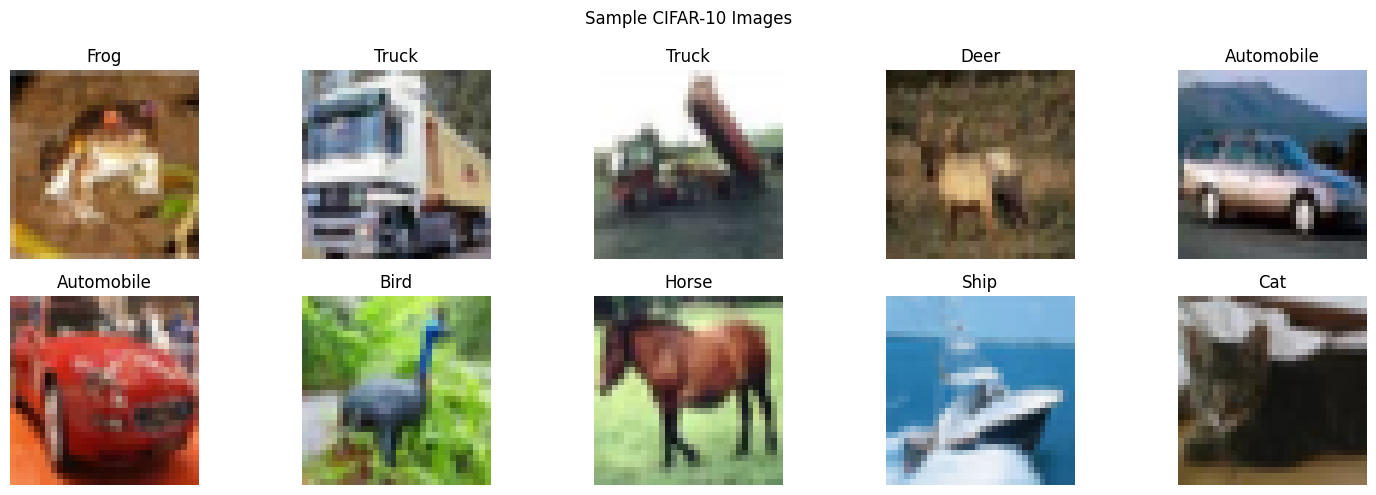

In [ ]:
# ============================================================
# TASK 1: DATASET PREPARATION
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 class names
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

# Display dataset dimensions
print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", x_test.shape)
print("Testing labels shape  :", y_test.shape)

# Display 10 sample images
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TASK 2: TRANSFER LEARNING USING MOBILENETV2
# ============================================================

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Number of classes
num_classes = 10

# Load MobileNetV2 pretrained on ImageNet
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze the convolutional base
base_model.trainable = False

# Build transfer learning model
inputs = layers.Input(shape=(32, 32, 3))

# Resize CIFAR-10 images to MobileNetV2 input size
x = layers.Resizing(96, 96)(inputs)

# Convert [0,1] pixels to [-1,1] expected by MobileNetV2
x = layers.Rescaling(scale=2.0, offset=-1.0)(x)

# Pretrained CNN
x = base_model(x, training=False)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Dense layer with ReLU
x = layers.Dense(128, activation="relu")(x)

# Output layer with Softmax
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Create model
model = models.Model(inputs, outputs)

# Display model architecture
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================================
# TASK 3: MODEL TRAINING
# ============================================================

import time
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Start training timer
start_time = time.time()

# Train the model
history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

# Training time
training_time = time.time() - start_time

print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 283s 197ms/step - accuracy: 0.8246 - loss: 0.5112 - val_accuracy: 0.8524 - val_loss: 0.4215
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 274s 194ms/step - accuracy: 0.8734 - loss: 0.3677 - val_accuracy: 0.8644 - val_loss: 0.3854
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 337s 205ms/step - accuracy: 0.8918 - loss: 0.3096 - val_accuracy: 0.8668 - val_loss: 0.3797
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 308s 195ms/step - accuracy: 0.9081 - loss: 0.2614 - val_accuracy: 0.8646 - val_loss: 0.4183
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 322s 195ms/step - accuracy: 0.9225 - loss: 0.2186 - val_accuracy: 0.8658 - val_loss: 0.4257
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 274s 195ms/step - accuracy: 0.9349 - loss: 0.1833 - val_accuracy: 0.8642 - val_loss: 0.4359
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 336s 205ms/step - accuracy: 0.9466 - loss: 0.1486 - val_accuracy: 0.8596 - val_loss: 0.4792
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 275s 195ms/step - ac

In [ ]:
# ============================================================
# TASK 4: FINE TUNING
# ============================================================

# Unfreeze the MobileNetV2 base model
base_model.trainable = True

# Freeze earlier layers
# Only the last ~30 layers will be fine-tuned
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much smaller learning rate
# This is important during fine-tuning.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune for 5 epochs
start_finetune_time = time.time()

fine_tune_history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

fine_tune_time = time.time() - start_finetune_time

print(f"\nFine-tuning Time: {fine_tune_time:.2f} seconds")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 463s 322ms/step - accuracy: 0.8590 - loss: 0.5787 - val_accuracy: 0.8606 - val_loss: 0.4970
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 514s 331ms/step - accuracy: 0.9251 - loss: 0.2207 - val_accuracy: 0.8712 - val_loss: 0.5037
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 452s 321ms/step - accuracy: 0.9485 - loss: 0.1548 - val_accuracy: 0.8730 - val_loss: 0.5088
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 501s 320ms/step - accuracy: 0.9564 - loss: 0.1273 - val_accuracy: 0.8780 - val_loss: 0.5411
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 517s 331ms/step - accuracy: 0.9641 - loss: 0.1030 - val_accuracy: 0.8788 - val_loss: 0.5489

Fine-tuning Time: 2449.74 seconds


In [ ]:
# ============================================================
# FINE-TUNING ACCURACY COMPARISON
# ============================================================

before_finetuning = max(history.history["val_accuracy"])
after_finetuning = max(fine_tune_history.history["val_accuracy"])

print("Best Validation Accuracy BEFORE Fine-Tuning:",
      f"{before_finetuning * 100:.2f}%")

print("Best Validation Accuracy AFTER Fine-Tuning:",
      f"{after_finetuning * 100:.2f}%")

improvement = (after_finetuning - before_finetuning) * 100

print("Improvement:",
      f"{improvement:.2f}%")

Best Validation Accuracy BEFORE Fine-Tuning: 86.68%
Best Validation Accuracy AFTER Fine-Tuning: 87.88%
Improvement: 1.20%


313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 180ms/step - accuracy: 0.8675 - loss: 0.6204

Test Accuracy: 86.75%
Test Loss: 0.6204
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 182ms/step

================ PERFORMANCE METRICS ================
Accuracy  : 86.75%
Precision : 87.16%
Recall    : 86.75%
F1-score  : 86.77%

================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

    Airplane       0.91      0.84      0.88      1000
  Automobile       0.91      0.95      0.93      1000
        Bird       0.89      0.82      0.86      1000
         Cat       0.76      0.78      0.77      1000
        Deer       0.87      0.83      0.85      1000
         Dog       0.79      0.83      0.81      1000
        Frog       0.80      0.96      0.88      1000
       Horse       0.94      0.83      0.89      1000
        Ship       0.97      0.87      0.92      1000
       Truck       0.87      0.95      0.91      1000

    accuracy                           0.87     10000

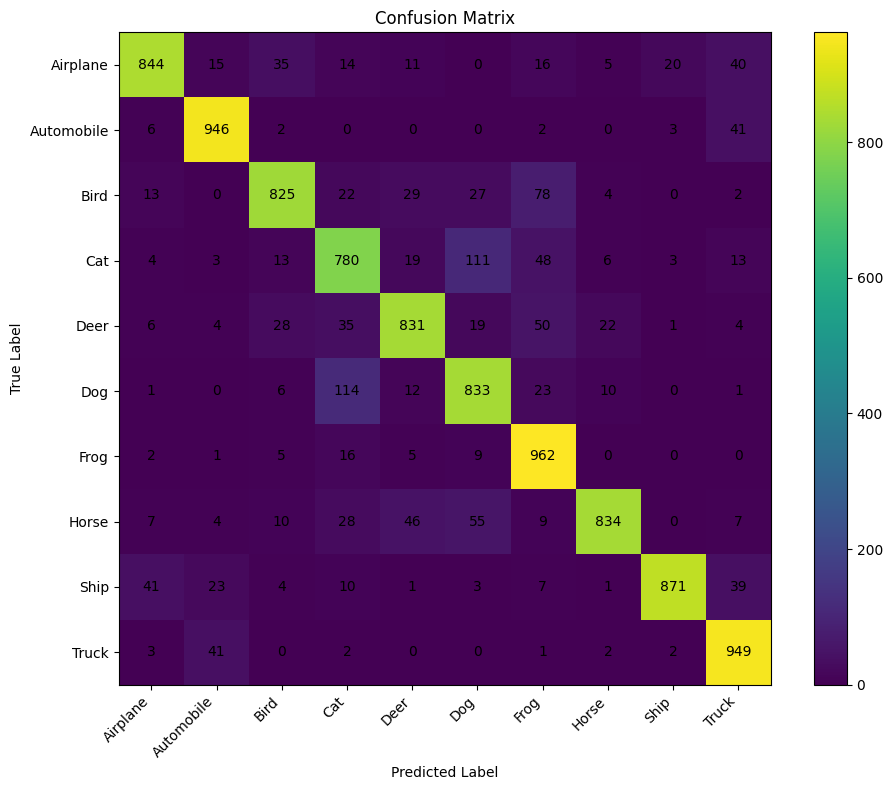

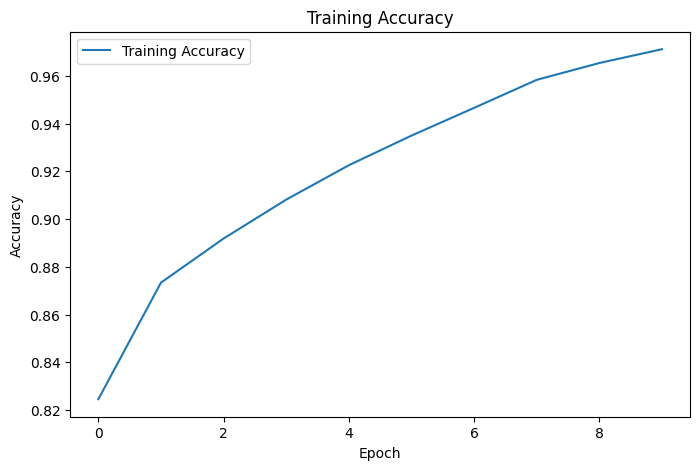

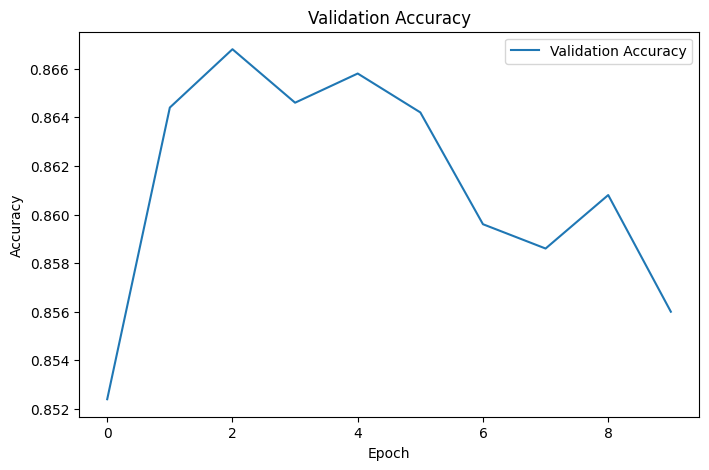

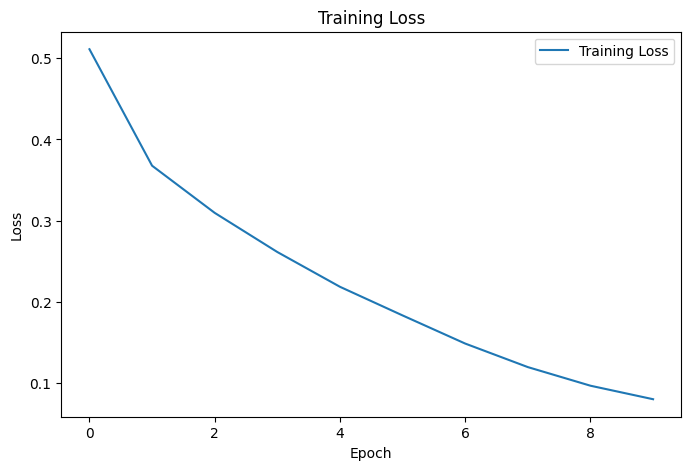

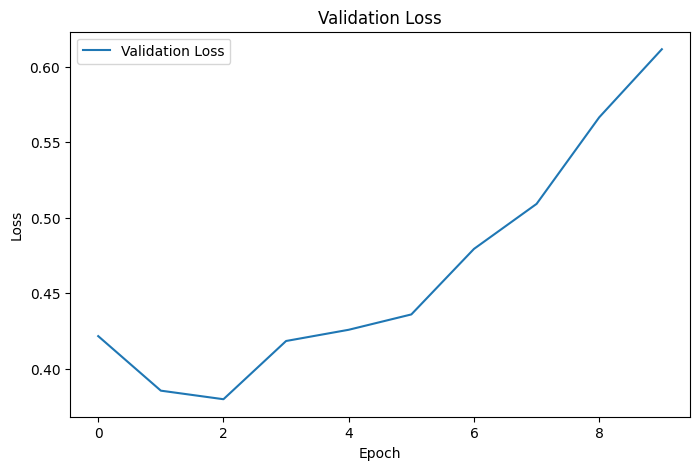

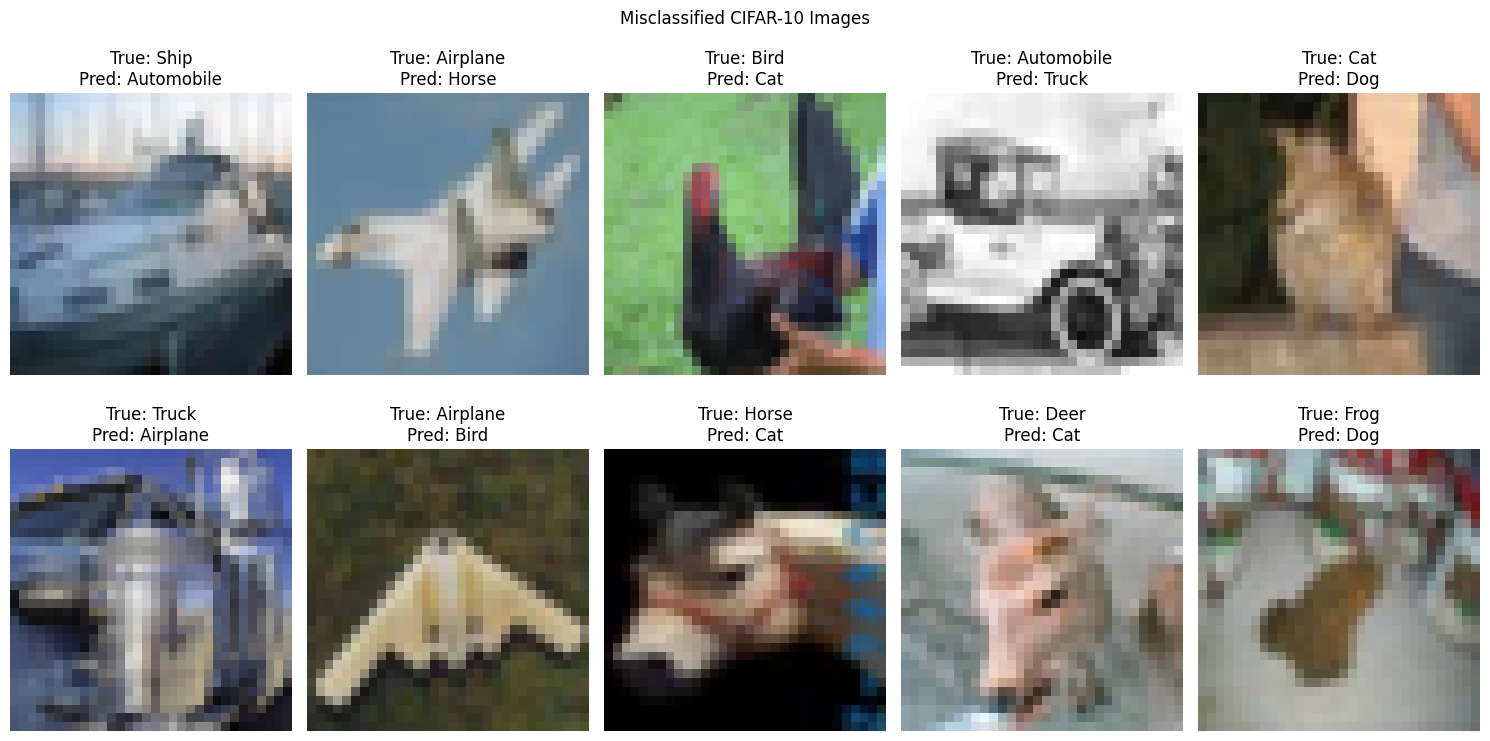


Trainable Parameters: 1691658


In [ ]:
# ============================================================
# TASK 5: MODEL EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Evaluate model on test data
# ------------------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    batch_size=32,
    verbose=1
)

print("\nTest Accuracy:", f"{test_accuracy * 100:.2f}%")
print("Test Loss:", f"{test_loss:.4f}")


# ------------------------------------------------------------
# 2. Generate predictions
# ------------------------------------------------------------

y_pred_probability = model.predict(
    x_test,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(y_pred_probability, axis=1)


# ------------------------------------------------------------
# 3. Calculate performance metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n================ PERFORMANCE METRICS ================")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-score  : {f1 * 100:.2f}%")


# ------------------------------------------------------------
# 4. Classification Report
# ------------------------------------------------------------

print("\n================ CLASSIFICATION REPORT ================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

# Display numbers inside matrix
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Training Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# ------------------------------------------------------------
# 7. Validation Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# ------------------------------------------------------------
# 8. Training Loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# ------------------------------------------------------------
# 9. Validation Loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# ------------------------------------------------------------
# 10. Optional: Misclassified Images
# ------------------------------------------------------------

misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 8))

for i, idx in enumerate(misclassified[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[idx])

    plt.title(
        f"True: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.suptitle("Misclassified CIFAR-10 Images")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Total trainable parameters
# ------------------------------------------------------------

trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_weights
])

print("\nTrainable Parameters:", trainable_params)